**BO1: Aide les entreprises à anticiper les métiers à recruter et adapter leurs plans RH et formation**
Classifier des métiers selon trajectoire 2024→2030(croissance / stable / déclin).

knn - tree, XGBoost, Logistic Regression

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                           precision_score, recall_score, f1_score, precision_recall_fscore_support,
                           balanced_accuracy_score, make_scorer)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_selection import SelectKBest, f_classif
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [93]:
df = pd.read_csv(r"C:\Users\meria\Downloads\mlProject\prepared_data.csv")
print(df.shape)
if 'Job_Status_num' not in df.columns:
    print("ERREUR: Colonne 'Job_Status_num' introuvable!")
    print(f"   Colonnes disponibles: {df.columns.tolist()}")
else:
    print(f"Target trouvée: Job_Status_num")

(10000, 29)
Target trouvée: Job_Status_num


**Load the prepared dataset**

In [94]:

df =  pd.read_csv(r"C:\Users\meria\Downloads\mlProject\prepared_data.csv")
print(f"Dataset shape: {df.shape}")

# Vérification de la target
if 'Job_Status_num' not in df.columns:
    print("ERREUR: Colonne 'Job_Status_num' introuvable!")
    print(f"   Colonnes disponibles: {df.columns.tolist()}")
else:
    print(f"Target trouvée: Job_Status_num")

Dataset shape: (10000, 29)
Target trouvée: Job_Status_num


**Check Job_Status_num distribution**

In [95]:
# Check Job_Status_num distribution
print("\n Distribution de Job_Status_num:")
print(df['Job_Status_num'].value_counts())
print(f"Proportions:\n{df['Job_Status_num'].value_counts(normalize=True)}")

# Verify the encoding mapping
job_status_mapping = {
    0.0: 'decreasing',
    1.0: 'increasing'
}
print(f"\n Job_Status_num mapping: {job_status_mapping}")


 Distribution de Job_Status_num:
Job_Status_num
-0.996207    5019
 1.003807    4981
Name: count, dtype: int64
Proportions:
Job_Status_num
-0.996207    0.5019
 1.003807    0.4981
Name: proportion, dtype: float64

 Job_Status_num mapping: {0.0: 'decreasing', 1.0: 'increasing'}


In [96]:
class_names = ['decreasing', 'increasing']
y_encoded = y.astype(int)  # Ensure it's integer type

print(f"\nClasses: {class_names}")
print(f"Class distribution: {dict(zip(class_names, np.bincount(y_encoded)))}")


Classes: ['decreasing', 'increasing']
Class distribution: {'decreasing': 5019, 'increasing': 4981}


**Prepare target variable**

In [97]:
target = "Job_Status_num"

# Remove leakage features and prepare X
LEAKAGE_FEATURES = [
    'Job_Growth_Rate_%',       
    'Growth_Category',          
    'Job_Status_num'           
]
X = df.select_dtypes(include=[np.number]).copy()
X = X.drop(columns=[col for col in LEAKAGE_FEATURES if col in X.columns], errors='ignore')
y = df[target].copy()

print(f"\nTarget variable: {target}")
print(f"Features used: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts().sort_index()}")
print(f"Target mapping: {job_status_mapping}")


Target variable: Job_Status_num
Features used: 25
Target distribution:
Job_Status_num
-0.996207    5019
 1.003807    4981
Name: count, dtype: int64
Target mapping: {0.0: 'decreasing', 1.0: 'increasing'}


**Split the data**

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nData Split:")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training target distribution: {dict(zip(class_names, np.bincount(y_train)))}")


Data Split:
Training set: (8000, 25)
Test set: (2000, 25)
Training target distribution: {'decreasing': 4015, 'increasing': 3985}


In [99]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle class imbalance with SMOTE (if needed)
print(f"\n Class balance check:")
print(f"Before SMOTE: {dict(zip(class_names, np.bincount(y_train)))}")

# Use SMOTE only if there's significant imbalance
if abs(np.bincount(y_train)[0] - np.bincount(y_train)[1]) / len(y_train) > 0.1:
    smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=3)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    print(f"After SMOTE: {dict(zip(class_names, np.bincount(y_train_smote)))}")
    X_train_final, y_train_final = X_train_smote, y_train_smote
else:
    X_train_final, y_train_final = X_train_scaled, y_train
    print("No SMOTE applied - classes are balanced enough")


 Class balance check:
Before SMOTE: {'decreasing': 4015, 'increasing': 3985}
No SMOTE applied - classes are balanced enough


# **KNN**

In [100]:
# KNN Baseline
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train, y_train)
y_pred_knn_baseline = knn_baseline.predict(X_test)
acc_knn_baseline = accuracy_score(y_test, y_pred_knn_baseline)


print(f" KNN Baseline - Accuracy: {acc_knn_baseline:.3f}")
print("\nRapport de classification KNN basique :")
print(classification_report(y_test, y_pred_knn_baseline, target_names=class_names))


 KNN Baseline - Accuracy: 0.492

Rapport de classification KNN basique :
              precision    recall  f1-score   support

  decreasing       0.49      0.51      0.50      1004
  increasing       0.49      0.48      0.48       996

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



**Optimisation KNN avec GridSearchCV**

In [101]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
# Utiliser balanced_accuracy comme métrique
knn_grid = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid_knn, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1
)
knn_grid.fit(X_train, y_train)   

best_knn = knn_grid.best_estimator_
y_pred_knn_opt = best_knn.predict(X_test)
acc_knn_opt = accuracy_score(y_test, y_pred_knn_opt)
bal_acc_knn = balanced_accuracy_score(y_test, y_pred_knn_opt)

**evaluation**

In [102]:
print(f" KNN OPTIMISÉ - Performances:")
print(f"   • Accuracy: {acc_knn_opt:.4f}")
print(f"   • Balanced Accuracy: {bal_acc_knn:.4f}")
print(f"   • Meilleurs paramètres: {knn_grid.best_params_}")

print("\nRapport de classification KNN optimisé :")
print(classification_report(y_test, y_pred_knn_opt, target_names=class_names))

 KNN OPTIMISÉ - Performances:
   • Accuracy: 0.5110
   • Balanced Accuracy: 0.5110
   • Meilleurs paramètres: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}

Rapport de classification KNN optimisé :
              precision    recall  f1-score   support

  decreasing       0.51      0.52      0.52      1004
  increasing       0.51      0.50      0.51       996

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



**visualisation**

**Matrice de confusion**

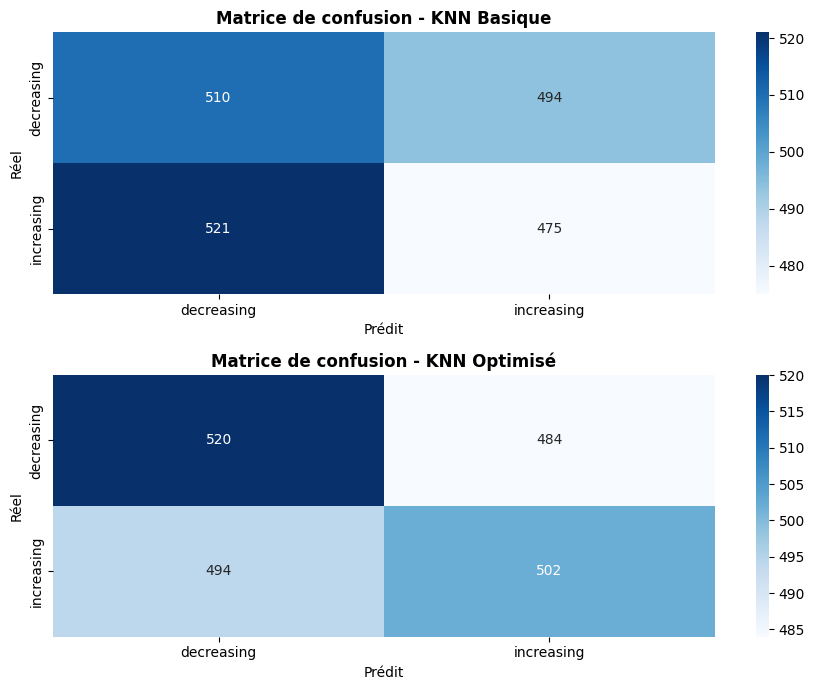

In [103]:
plt.figure(figsize=(9, 7))
plt.subplot(2, 1, 1)
cm_basic = confusion_matrix(y_test, y_pred_knn_baseline)
sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)  # Correction: class_names
plt.title("Matrice de confusion - KNN Basique", fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')

plt.subplot(2, 1, 2)
cm_opt = confusion_matrix(y_test, y_pred_knn_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)  # Correction: class_names
plt.title("Matrice de confusion - KNN Optimisé", fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

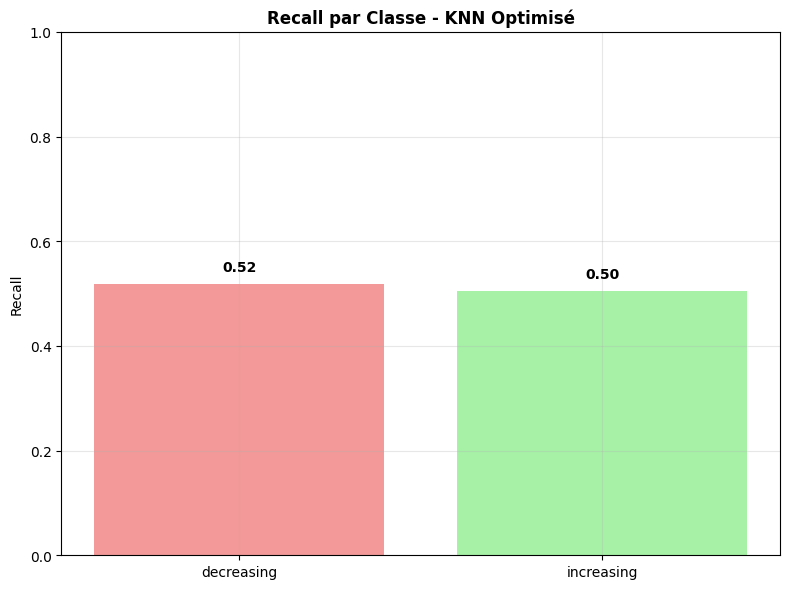

In [104]:
plt.figure(figsize=(8, 6))
recall_knn = recall_score(y_test, y_pred_knn_opt, average=None)
plt.bar(class_names, recall_knn, color=['lightcoral', 'lightgreen'], alpha=0.8)  # Correction: 2 couleurs seulement
plt.title('Recall par Classe - KNN Optimisé', fontweight='bold')
plt.ylabel('Recall')
plt.ylim(0, 1)
for i, v in enumerate(recall_knn):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

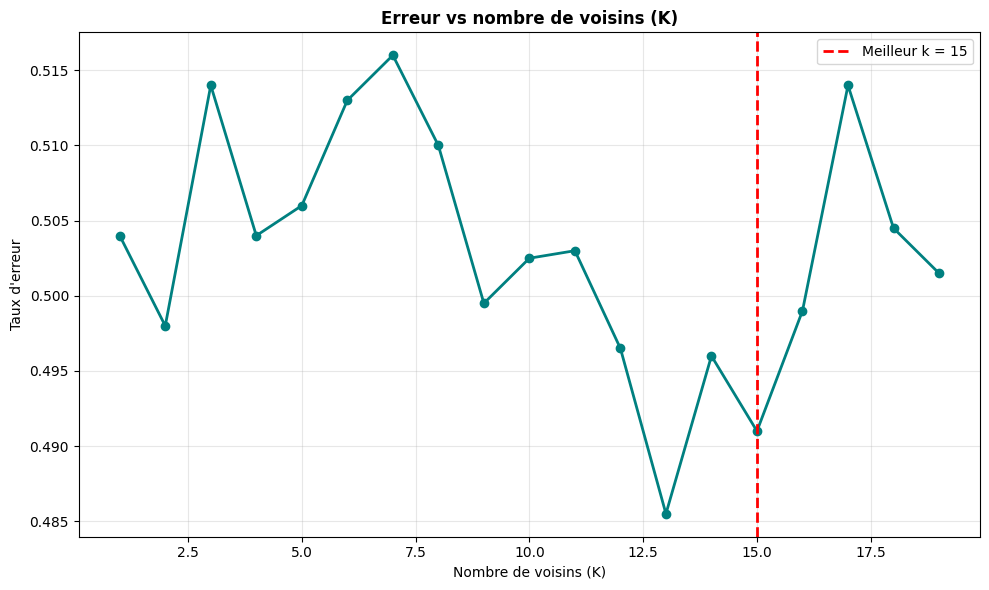

In [105]:
plt.figure(figsize=(10, 6))
errors = []
neighbors_range = range(1, 20)
for k in neighbors_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred_k = model.predict(X_test_scaled)
    errors.append(1 - accuracy_score(y_test, pred_k))

plt.plot(neighbors_range, errors, marker='o', linestyle='-', color='teal', linewidth=2, markersize=6)
plt.axvline(x=knn_grid.best_params_['n_neighbors'], color='red', linestyle='--', 
            label=f'Meilleur k = {knn_grid.best_params_["n_neighbors"]}', linewidth=2)
plt.title("Erreur vs nombre de voisins (K)", fontweight='bold')
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Taux d'erreur")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# **Modèle Arbre de Décision** 


In [106]:
# Arbre Baseline
tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train, y_train)
y_pred_tree_baseline = tree_baseline.predict(X_test)
acc_tree_baseline = accuracy_score(y_test, y_pred_tree_baseline)

In [107]:

print(f"Arbre Baseline (défaut) - Accuracy: {acc_tree_baseline:.3f}")
print(f"   • Profondeur: {tree_baseline.get_depth()}")
print(f"   • Feuilles: {tree_baseline.get_n_leaves()}")

Arbre Baseline (défaut) - Accuracy: 0.508
   • Profondeur: 37
   • Feuilles: 1969


**Optimisation Arbre**

In [108]:
tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train, y_train)
y_pred_tree_baseline = tree_baseline.predict(X_test)
acc_tree_baseline = accuracy_score(y_test, y_pred_tree_baseline)

print(f"Arbre Baseline (défaut) - Accuracy: {acc_tree_baseline:.3f}")
print(f"  Profondeur: {tree_baseline.get_depth()}")
print(f"  Feuilles: {tree_baseline.get_n_leaves()}")

Arbre Baseline (défaut) - Accuracy: 0.508
  Profondeur: 37
  Feuilles: 1969


**Optimisation Arbre avec GridSearchCV**

In [109]:
param_grid_tree = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', {0:1, 1:1}],  # Correction: seulement 2 classes
    'max_features': ['sqrt', 'log2', None]
}

grid_search_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_tree.fit(X_train_final, y_train_final)  # Utiliser les données finales



Fitting 5 folds for each of 540 candidates, totalling 2700 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced', {0: 1, 1: 1}], 'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [110]:
best_tree = grid_search_tree.best_estimator_
y_pred_tree = best_tree.predict(X_test)  # Pas de scaling pour les arbres
acc_tree = accuracy_score(y_test, y_pred_tree)
bal_acc_tree = balanced_accuracy_score(y_test, y_pred_tree)

print(f"ARBRE OPTIMISÉ - Performances:")
print(f"  • Accuracy: {acc_tree:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_tree:.4f}")
print(f"  • Meilleurs paramètres: {grid_search_tree.best_params_}")

ARBRE OPTIMISÉ - Performances:
  • Accuracy: 0.5100
  • Balanced Accuracy: 0.5096
  • Meilleurs paramètres: {'class_weight': {0: 1, 1: 1}, 'criterion': 'gini', 'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 10}


In [111]:
print("\nRapport de classification Arbre optimisé :")
print(classification_report(y_test, y_pred_tree, target_names=class_names))


Rapport de classification Arbre optimisé :
              precision    recall  f1-score   support

  decreasing       0.51      0.61      0.56      1004
  increasing       0.51      0.40      0.45       996

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.51      0.51      0.50      2000



**Validation Croisée Arbre**


In [112]:
cv_scores_tree = cross_val_score(best_tree, X_train, y_train, cv=5, scoring='accuracy')
print(f"\nVALIDATION CROISÉE ARBRE:")
print(f"  • Scores CV: {[f'{s:.4f}' for s in cv_scores_tree]}")
print(f"  • Moyenne:   {cv_scores_tree.mean():.4f} (± {cv_scores_tree.std():.4f})")

# Importance des features
importances_tree = pd.Series(best_tree.feature_importances_, index=X.columns)
importances_tree = importances_tree.sort_values(ascending=False)
top_features_tree = importances_tree[importances_tree > 0].head(15)

print(f"\nTOP {len(top_features_tree)} FEATURES IMPORTANTES - ARBRE:")
for i, (feature, importance) in enumerate(top_features_tree.items(), 1):
   
    print(f"   {i:2d}. {feature:35} {importance:7.4f} ")


VALIDATION CROISÉE ARBRE:
  • Scores CV: ['0.4981', '0.5162', '0.5150', '0.4781', '0.4963']
  • Moyenne:   0.5007 (± 0.0140)

TOP 15 FEATURES IMPORTANTES - ARBRE:
    1. Median_Salary_USD                    0.1494 
    2. Gender_Diversity_%                   0.1429 
    3. Job_Value_Index                      0.1354 
    4. Remote_Work_Ratio_%                  0.1172 
    5. Vulnerability_Index                  0.1116 
    6. Automation_Risk_%                    0.1061 
    7. Required_Education_num               0.0705 
    8. Experience_Required_Years            0.0685 
    9. Location_canada                      0.0161 
   10. Location_china                       0.0157 
   11. Location_brazil                      0.0126 
   12. Industry_education                   0.0086 
   13. Industry_finance                     0.0081 
   14. AI_Impact_Level_num                  0.0065 
   15. Location_germany                     0.0057 


**Visualisations Arbre**


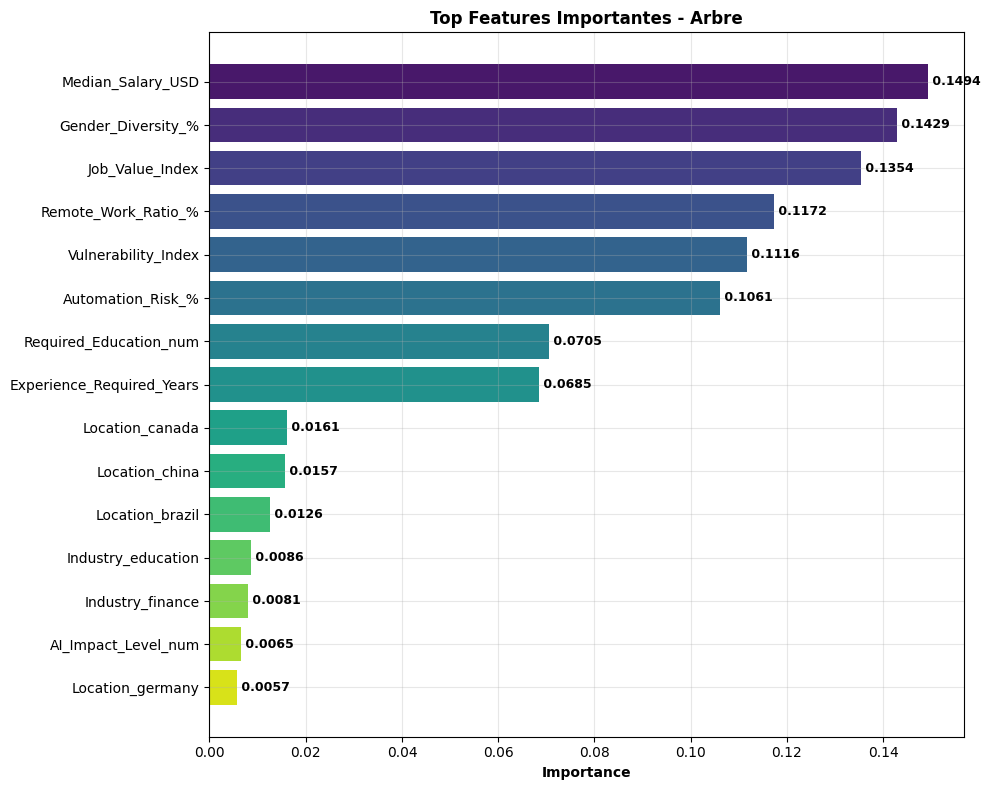

In [113]:
plt.figure(figsize=(10, 8))
colors = sns.color_palette("viridis", len(top_features_tree))
bars = plt.barh(range(len(top_features_tree)), top_features_tree.values, color=colors)
plt.yticks(range(len(top_features_tree)), top_features_tree.index)
plt.xlabel('Importance', fontweight='bold')
plt.title('Top Features Importantes - Arbre', fontweight='bold')
plt.gca().invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, top_features_tree.values)):
    plt.text(val, i, f' {val:.4f}', va='center', fontsize=9, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

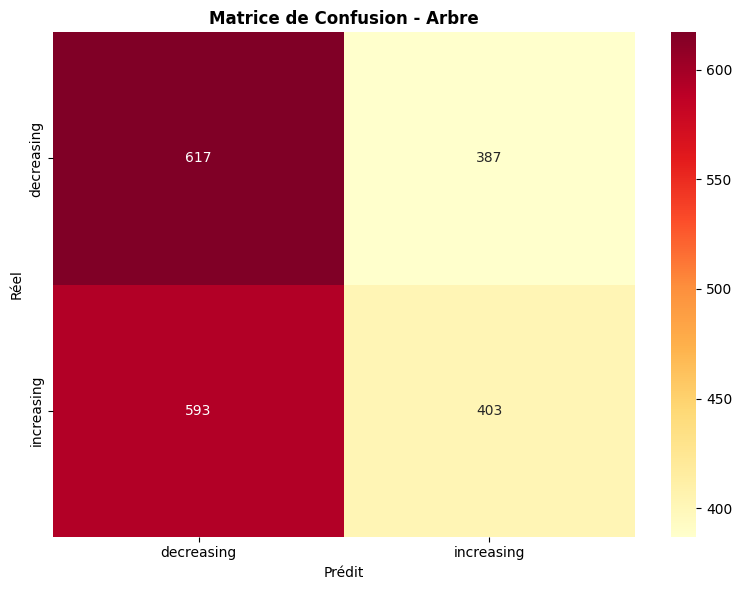

In [114]:
plt.figure(figsize=(8, 6))
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names)  # Correction: class_names
plt.title('Matrice de Confusion - Arbre', fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

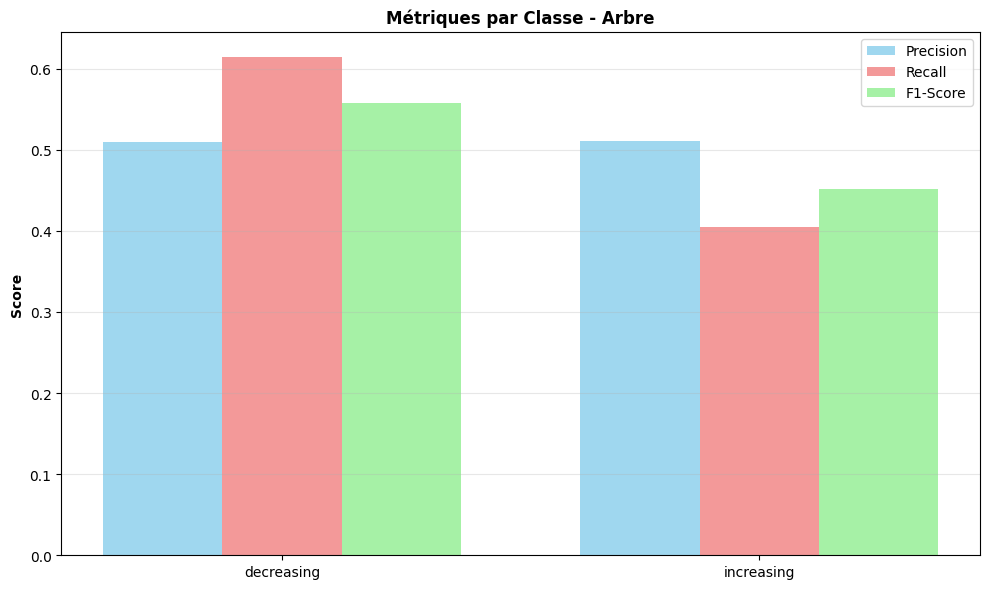

In [115]:
plt.figure(figsize=(10, 6))
precision_tree, recall_tree, f1_tree, _ = precision_recall_fscore_support(y_test, y_pred_tree, average=None)
x_pos = np.arange(len(class_names))
width = 0.25
plt.bar(x_pos - width, precision_tree, width, label='Precision', alpha=0.8, color='skyblue')
plt.bar(x_pos, recall_tree, width, label='Recall', alpha=0.8, color='lightcoral')
plt.bar(x_pos + width, f1_tree, width, label='F1-Score', alpha=0.8, color='lightgreen')
plt.ylabel('Score', fontweight='bold')
plt.title('Métriques par Classe - Arbre', fontweight='bold')
plt.xticks(x_pos, class_names)  # Correction: class_names
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

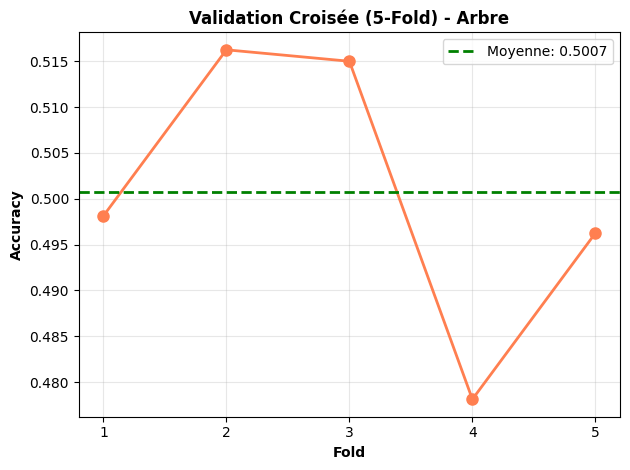

In [116]:
plt.plot(range(1, 6), cv_scores_tree, 'o-', linewidth=2, markersize=8, color='coral')
plt.axhline(cv_scores_tree.mean(), color='green', linestyle='--', 
           label=f'Moyenne: {cv_scores_tree.mean():.4f}', linewidth=2)
plt.xlabel('Fold', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Validation Croisée (5-Fold) - Arbre', fontweight='bold')
plt.xticks(range(1, 6))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

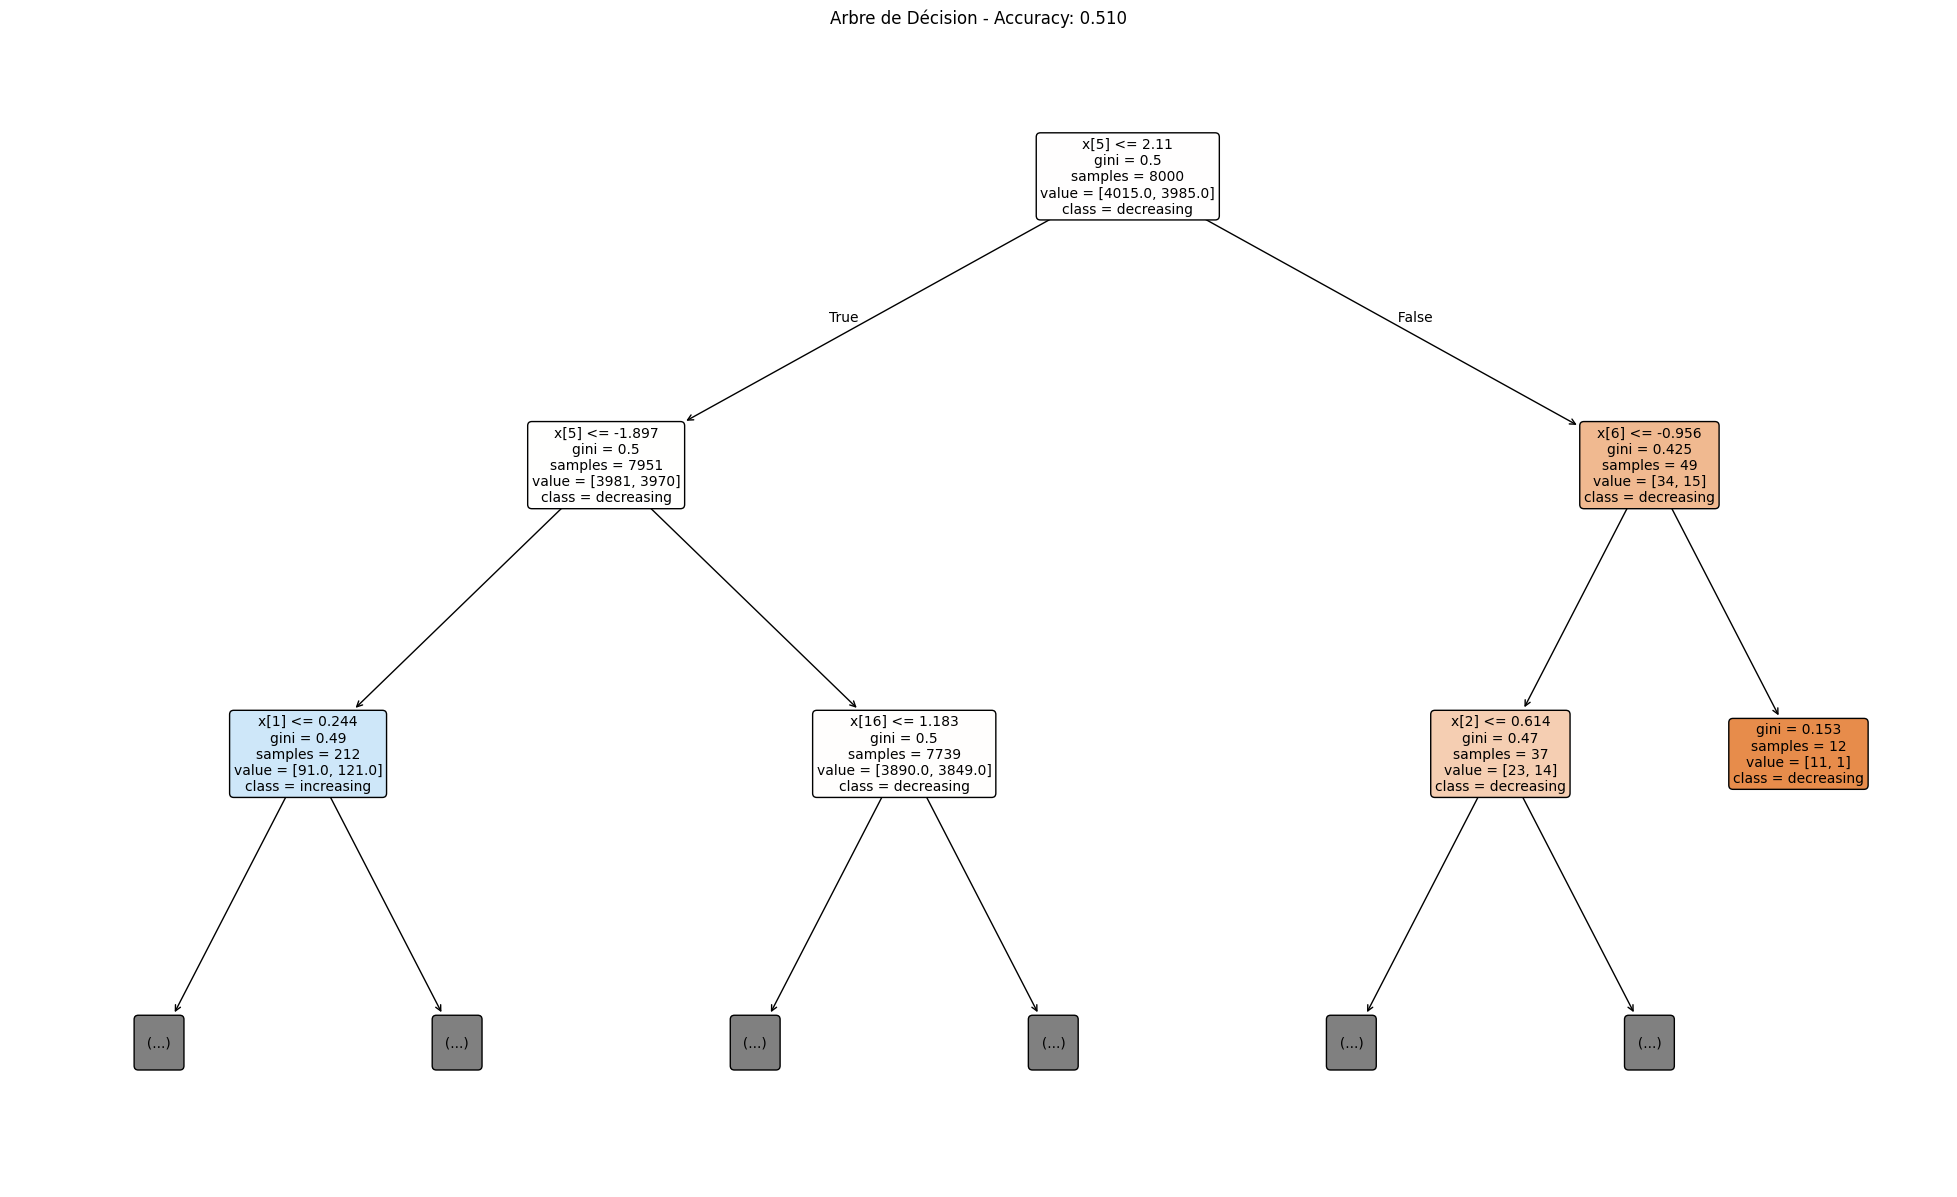

In [117]:
fig = plt.figure(figsize=(25, 15))
plot_tree(best_tree,
         class_names=class_names,
         filled=True,
         rounded=True,
         fontsize=10,
         max_depth=2)  # Show only 2 levels
plt.title(f'Arbre de Décision - Accuracy: {acc_tree:.3f}')
plt.show()

# **Régression Linéaire**


In [118]:
# Regression Baseline
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr_baseline = lr_baseline.predict(X_test_scaled)
acc_lr_baseline = accuracy_score(y_test, y_pred_lr_baseline)

print(f"Regression Baseline - Accuracy: {acc_lr_baseline:.3f}")

Regression Baseline - Accuracy: 0.514


In [119]:
# Optimisation Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', {0:1, 1:1, 2:3}]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)
print("Recherche des meilleurs paramètres pour la regression...")
lr_grid.fit(X_train, y_train)

Recherche des meilleurs paramètres pour la regression...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.001, 0.01, ...], 'class_weight': ['balanced', {0: 1, 1: 1, 2: 3}], 'penalty': ['l1', 'l2', ...], 'solver': ['liblinear', 'saga']}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [120]:
best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)

print(f" RÉGRESSION OPTIMISÉE - Performances:")
print(f"  • Accuracy: {acc_lr:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_lr:.4f}")
print(f"  • Meilleurs paramètres: {lr_grid.best_params_}")



 RÉGRESSION OPTIMISÉE - Performances:
  • Accuracy: 0.5230
  • Balanced Accuracy: 0.5230
  • Meilleurs paramètres: {'C': 0.001, 'class_weight': {0: 1, 1: 1, 2: 3}, 'penalty': 'l2', 'solver': 'saga'}


In [121]:
print("\n Rapport de classification Regression optimisée :")
print(classification_report(y_test, y_pred_lr, target_names=class_names))


 Rapport de classification Regression optimisée :
              precision    recall  f1-score   support

  decreasing       0.52      0.53      0.53      1004
  increasing       0.52      0.52      0.52       996

    accuracy                           0.52      2000
   macro avg       0.52      0.52      0.52      2000
weighted avg       0.52      0.52      0.52      2000



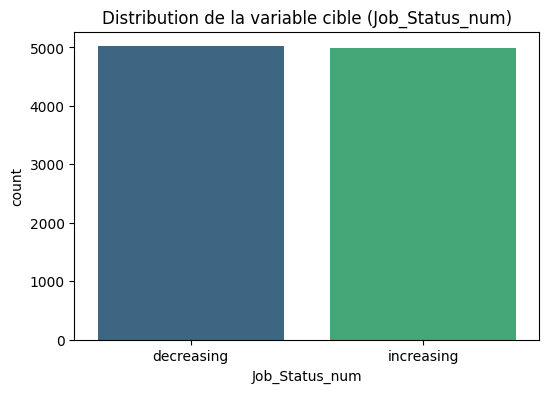

In [122]:
plt.figure(figsize=(6,4))
sns.countplot(x=y, palette="viridis")
plt.title("Distribution de la variable cible (Job_Status_num)")
plt.xticks([0,1], ["decreasing", "increasing"])
plt.show()

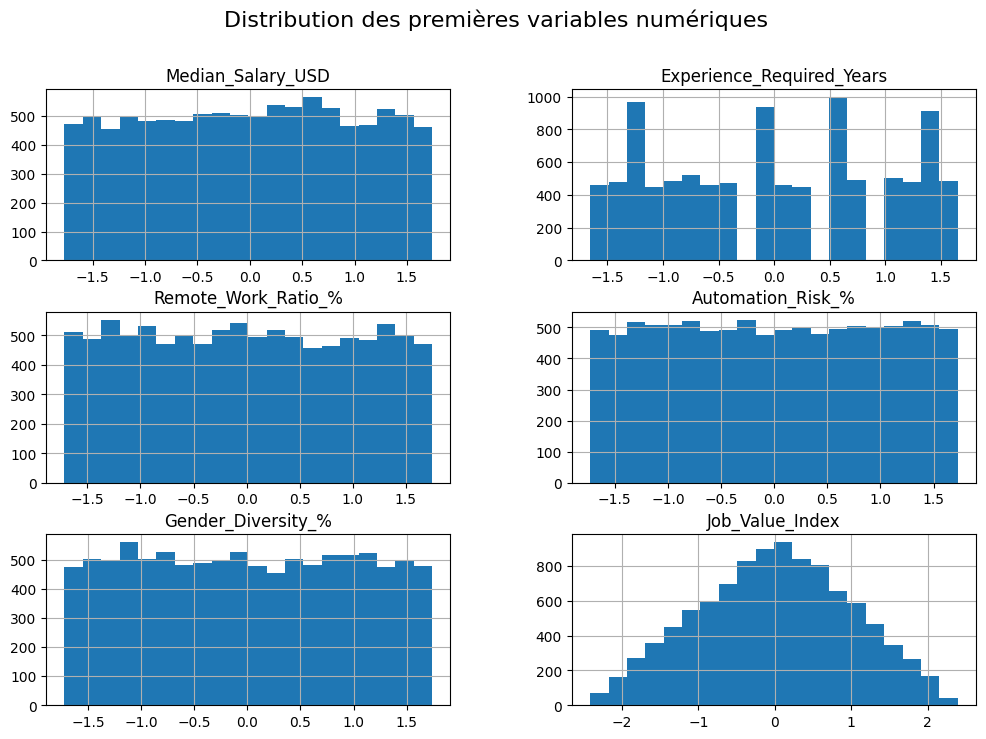

In [123]:
numeric_cols = X.columns[:6]  # les 6 premières pour éviter un énorme plot

df[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution des premières variables numériques", fontsize=16)
plt.show()

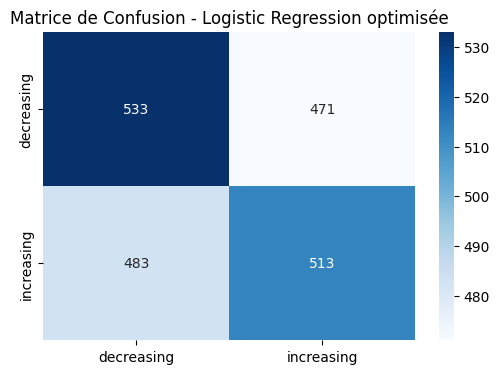

In [124]:

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice de Confusion - Logistic Regression optimisée")
plt.show()


ROC Curve 

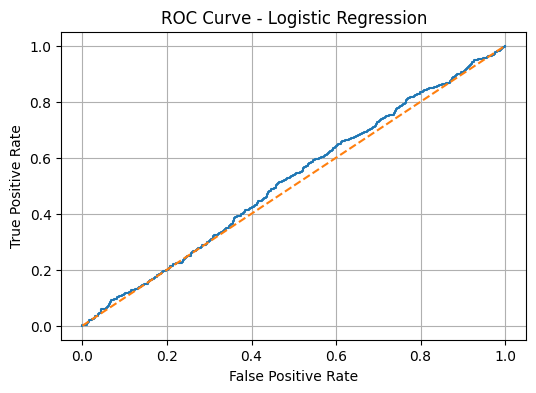

AUC = 0.5177572841165459


In [125]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba_lr = best_lr.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_lr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], '--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.show()

print("AUC =", roc_auc_score(y_test, y_pred_proba_lr))


**Polynomial**

In [126]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("Dimensions avant:", X_train_scaled.shape)
print("Dimensions après:", X_train_poly.shape)


Dimensions avant: (8000, 25)
Dimensions après: (8000, 350)


In [127]:
lr_poly = LogisticRegression(max_iter=5000, solver="saga")
lr_poly.fit(X_train_poly, y_train_final)

y_pred_poly = lr_poly.predict(X_test_poly)

acc_poly = accuracy_score(y_test, y_pred_poly)
bal_acc_poly = balanced_accuracy_score(y_test, y_pred_poly)

print(f" Régression polynomiale - Performances :")
print(f"  • Accuracy: {acc_poly:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_poly:.4f}")

print("\n Rapport de classification (Régression polynomiale) :")
print(classification_report(y_test, y_pred_poly, target_names=class_names))


 Régression polynomiale - Performances :
  • Accuracy: 0.5225
  • Balanced Accuracy: 0.5224

 Rapport de classification (Régression polynomiale) :
              precision    recall  f1-score   support

  decreasing       0.52      0.54      0.53      1004
  increasing       0.52      0.50      0.51       996

    accuracy                           0.52      2000
   macro avg       0.52      0.52      0.52      2000
weighted avg       0.52      0.52      0.52      2000



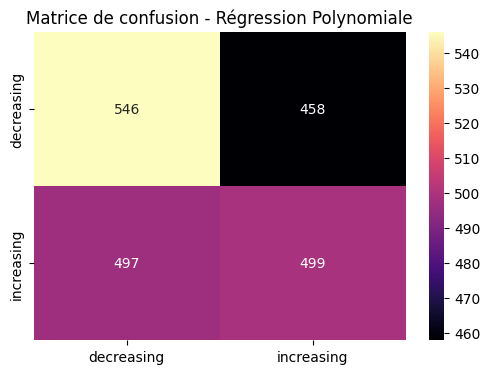

In [128]:
cm_poly = confusion_matrix(y_test, y_pred_poly)

plt.figure(figsize=(6,4))
sns.heatmap(cm_poly, annot=True, fmt="d", cmap="magma",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice de confusion - Régression Polynomiale")
plt.show()


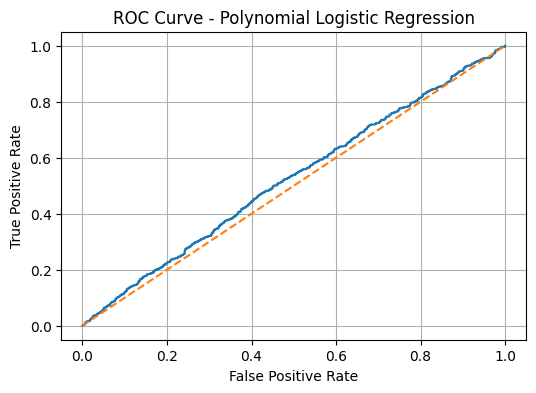

AUC = 0.5232893726299621


In [129]:
y_pred_proba_poly = lr_poly.predict_proba(X_test_poly)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_poly)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], '--')
plt.title("ROC Curve - Polynomial Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.show()

print("AUC =", roc_auc_score(y_test, y_pred_proba_poly))


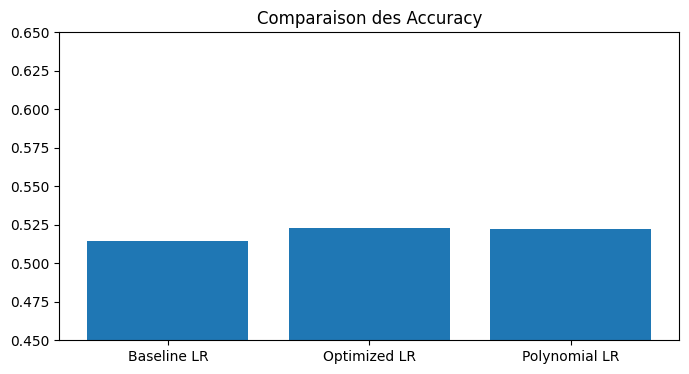

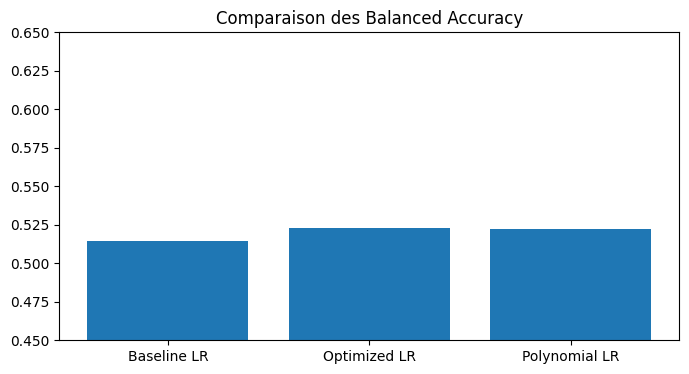

In [130]:
models = ["Baseline LR", "Optimized LR", "Polynomial LR"]
accuracies = [acc_lr_baseline, acc_lr, acc_poly]
bal_accuracies = [balanced_accuracy_score(y_test, y_pred_lr_baseline),
                  bal_acc_lr, bal_acc_poly]

plt.figure(figsize=(8,4))
plt.bar(models, accuracies)
plt.ylim(0.45, 0.65)
plt.title("Comparaison des Accuracy")
plt.show()

plt.figure(figsize=(8,4))
plt.bar(models, bal_accuracies)
plt.ylim(0.45, 0.65)
plt.title("Comparaison des Balanced Accuracy")
plt.show()


# **XGboost**

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

In [132]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder # Added for potential label encoding if needed
import pandas as pd


xgb_baseline = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

xgb_baseline.fit(X_train, y_train)
y_pred_xgb_baseline = xgb_baseline.predict(X_test)

acc_xgb_baseline = accuracy_score(y_test, y_pred_xgb_baseline)
bal_acc_xgb_baseline = balanced_accuracy_score(y_test, y_pred_xgb_baseline)

print(f"Accuracy: {acc_xgb_baseline:.4f}")
print(f"Balanced Accuracy: {bal_acc_xgb_baseline:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_baseline, target_names=class_names))
print("Modèle XGBoost entraîné avec succès!")

Accuracy: 0.4875
Balanced Accuracy: 0.4874

Classification Report:
              precision    recall  f1-score   support

  decreasing       0.49      0.51      0.50      1004
  increasing       0.48      0.47      0.48       996

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000

Modèle XGBoost entraîné avec succès!


In [133]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}
model_for_grid_search = xgb.XGBClassifier(
   objective='binary:logistic', 
    eval_metric='logloss',     
    use_label_encoder=False,
    random_state=42
)
grid_search = GridSearchCV(
     estimator=model_for_grid_search,
    param_grid=param_grid,
    cv=3, 
    scoring='accuracy',
    verbose=2,
    n_jobs=-1 
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(grid_search.best_score_))

Starting Grid Search...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters found:  {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best cross-validation accuracy: 0.5116


### K-Fold Cross-Validation for the Initial XGBoost Model

In [134]:
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import numpy as np

initial_model_bo1 = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

num_folds = 5 # You can change the number of folds
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

cv_scores = []

print(f"Performing {num_folds}-Fold Cross-Validation...")

# Use X (features) and y_encoded (label-encoded Job_Status_num) for cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X, y_encoded)):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y_encoded[train_index], y_encoded[val_index] # Use y_encoded

    # Train the model on the training fold
    initial_model_bo1.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation fold
    y_pred_fold = initial_model_bo1.predict(X_val_fold)

    # Calculate accuracy for this fold
    fold_accuracy = accuracy_score(y_val_fold, y_pred_fold)
    cv_scores.append(fold_accuracy)
    print(f"Fold {fold+1} Accuracy: {fold_accuracy:.4f}")

print(f"\nMean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"Std Dev CV Accuracy: {np.std(cv_scores):.4f}")

Performing 5-Fold Cross-Validation...
Fold 1 Accuracy: 0.4975
Fold 2 Accuracy: 0.5085
Fold 3 Accuracy: 0.4845
Fold 4 Accuracy: 0.5015
Fold 5 Accuracy: 0.4820

Mean CV Accuracy: 0.4948
Std Dev CV Accuracy: 0.0101


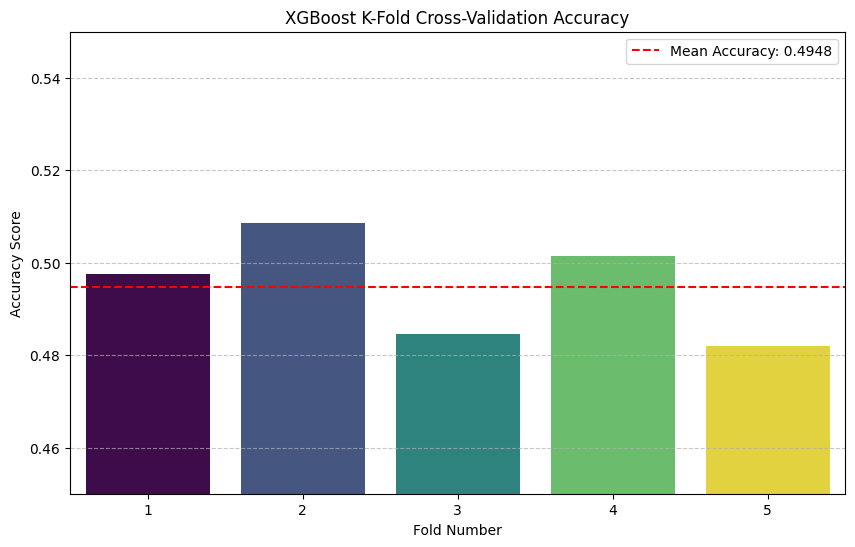

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Ensure numpy is imported for np.mean

cv_results_df = pd.DataFrame({
    'Fold': range(1, num_folds + 1),
    'Accuracy': cv_scores
})
plt.figure(figsize=(10, 6))
sns.barplot(x='Fold', y='Accuracy', data=cv_results_df, palette='viridis', hue='Fold', legend=False)
plt.axhline(y=np.mean(cv_scores), color='r', linestyle='--', label=f'Mean Accuracy: {np.mean(cv_scores):.4f}')
plt.title('XGBoost K-Fold Cross-Validation Accuracy')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy Score')
plt.ylim(0.45, 0.55) # Adjusted y-axis for better visualization of current scores
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##Implement Random Search

In [137]:
# Optimization with Random Search
param_dist_xgb = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'min_child_weight': randint(1, 10)
}

xgb_random = RandomizedSearchCV(
    xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, verbosity=0),
    param_dist_xgb,
    n_iter=30,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
xgb_random.fit(X_train_final, y_train_final)

best_xgb = xgb_random.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]
acc_xgb = accuracy_score(y_test, y_pred_xgb)
bal_acc_xgb = balanced_accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"Optimized XGBoost - Accuracy: {acc_xgb:.4f} | Balanced Acc: {bal_acc_xgb:.4f} | AUC: {auc_xgb:.4f}")
print(f"Best params: {xgb_random.best_params_}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

# Feature importance
importance_xgb = pd.Series(best_xgb.feature_importances_, index=X.columns)
importance_xgb = importance_xgb.sort_values(ascending=False)
print(f"\nTop 5 Important Features:")
for i, (feat, imp) in enumerate(importance_xgb.head(5).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

Optimized XGBoost - Accuracy: 0.4970 | Balanced Acc: 0.4970 | AUC: 0.4998
Best params: {'colsample_bytree': 0.749816047538945, 'gamma': 4.75357153204958, 'learning_rate': 0.22959818254342154, 'max_depth': 7, 'min_child_weight': 7, 'n_estimators': 171, 'subsample': 0.662397808134481}

Classification Report:
              precision    recall  f1-score   support

  decreasing       0.50      0.50      0.50      1004
  increasing       0.49      0.49      0.49       996

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000


Top 5 Important Features:
  1. Location_canada: 0.0757
  2. Location_india: 0.0533
  3. Vulnerability_Index: 0.0511
  4. Required_Education_num: 0.0501
  5. Median_Salary_USD: 0.0500


In [138]:
# 1. Obtenir le modèle XGBoost optimisé et ses prédictions
best_xgb_model = grid_search.best_estimator_
y_pred_xgb_opt = best_xgb_model.predict(X_test)

# 2. Calculer les métriques pour le modèle optimisé
acc_xgb_opt = accuracy_score(y_test, y_pred_xgb_opt)
bal_acc_xgb_opt = balanced_accuracy_score(y_test, y_pred_xgb_opt)

print(f"\nXGBoost Optimisé - Performances:")
print(f"  • Accuracy: {acc_xgb_opt:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_xgb_opt:.4f}")
print(f"  • Meilleurs paramètres: {grid_search.best_params_}")

print("\nClassification Report - XGBoost Optimisé:")
print(classification_report(y_test, y_pred_xgb_opt, target_names=class_names))


XGBoost Optimisé - Performances:
  • Accuracy: 0.5070
  • Balanced Accuracy: 0.5069
  • Meilleurs paramètres: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}

Classification Report - XGBoost Optimisé:
              precision    recall  f1-score   support

  decreasing       0.51      0.52      0.51      1004
  increasing       0.51      0.49      0.50       996

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



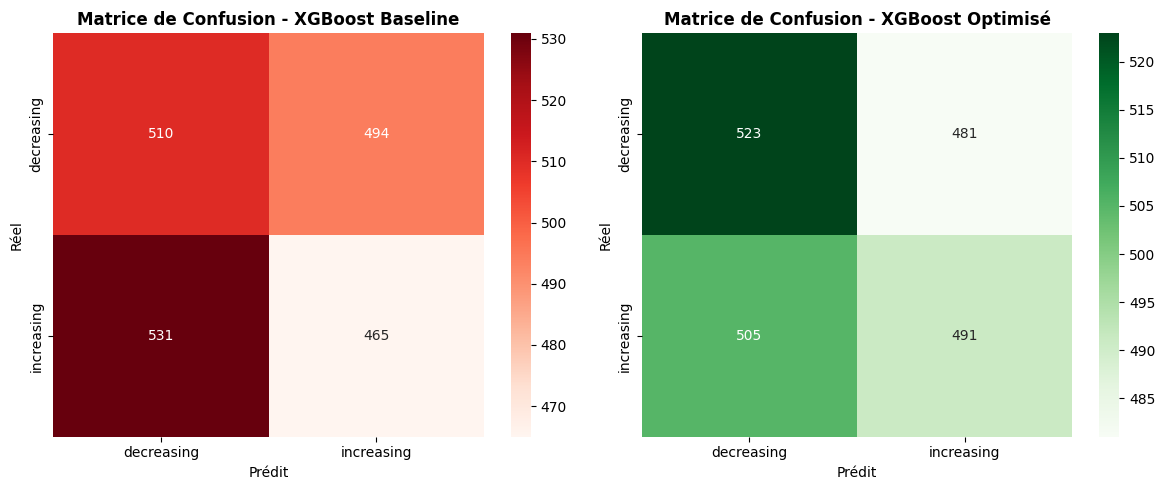

In [139]:
# 3. Matrice de confusion corrigée
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm_xgb_baseline = confusion_matrix(y_test, y_pred_xgb_baseline)
sns.heatmap(cm_xgb_baseline, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - XGBoost Baseline', fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')

plt.subplot(1, 2, 2)
cm_xgb_opt = confusion_matrix(y_test, y_pred_xgb_opt)
sns.heatmap(cm_xgb_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - XGBoost Optimisé', fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')

plt.tight_layout()
plt.show()


##Compare Search Results

In [141]:
best_params_grid = grid_search.best_params_
best_score_grid = grid_search.best_score_

best_params_random = xgb_random.best_params_
best_score_random = xgb_random.best_score_

print("COMPARISON OF HYPERPARAMETER SEARCH RESULTS")

print("\n--- Grid Search Results ---")
print(f"Best Parameters: {best_params_grid}")
print(f"Best Cross-Validation Accuracy: {best_score_grid:.4f}")

print("\n--- Random Search Results ---")
print(f"Best Parameters: {best_params_random}")
print(f"Best Cross-Validation Accuracy: {best_score_random:.4f}")

print("CONCLUSION")

if best_score_grid > best_score_random:
    print(f"Grid Search yielded a better model configuration with an accuracy of {best_score_grid:.4f}.")
    print(f"Optimal Parameters (Grid Search): {best_params_grid}")
elif best_score_random > best_score_grid:
    print(f"Random Search yielded a better model configuration with an accuracy of {best_score_random:.4f}.")
    print(f"Optimal Parameters (Random Search): {best_params_random}")
else:
    print(f"Both Grid Search and Random Search yielded the same best accuracy of {best_score_grid:.4f}.")
    print(f"Optimal Parameters (Grid Search): {best_params_grid}")
    print(f"Optimal Parameters (Random Search): {best_params_random}")

COMPARISON OF HYPERPARAMETER SEARCH RESULTS

--- Grid Search Results ---
Best Parameters: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best Cross-Validation Accuracy: 0.5116

--- Random Search Results ---
Best Parameters: {'colsample_bytree': 0.749816047538945, 'gamma': 4.75357153204958, 'learning_rate': 0.22959818254342154, 'max_depth': 7, 'min_child_weight': 7, 'n_estimators': 171, 'subsample': 0.662397808134481}
Best Cross-Validation Accuracy: 0.5050
CONCLUSION
Grid Search yielded a better model configuration with an accuracy of 0.5116.
Optimal Parameters (Grid Search): {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
